[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/anmedinas/score_matching/blob/main/notebooks/orquestador_colab.ipynb)

## **Score Matching** 🎖️

**Notebook Orquestador**

Andrés C. Medina Sanhueza

Senior Data Scientist Engineer

anmedinas@gmail.com

# Entrenamiento real en GPU (Colab)

La finalidad de este notebook, es orquestar todo el *pipeline* de desarrollo del modelo de *score matching* utilizando GPU de colab. Para ello, lo primero que se debe hacer es clonar el repositorio de GitHub y ejecutar los módulos `download_data.py`, `train.py` (dos veces: red condicional pura y red con CFG) y `train_clf.py` (el checkpoint resultante queda ligado a un commit concreto, no a una copia pegada en una celda). Con los tres checkpoints entrenados, el notebook cierra el ciclo generando muestras (`sample.py`) y evaluándolas cuantitativamente contra el clasificador (`evaluate.py`), para terminar empaquetando todos los resultados en un `.zip` descargable.

**Antes de correr**: `Entorno de ejecucion -> Cambiar tipo de entorno de
ejecucion -> GPU`.

In [1]:
import torch

print("CUDA disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
else:
    print("ADVERTENCIA: sin GPU. Entorno de ejecucion -> Cambiar tipo -> GPU.")

CUDA disponible: True
Tesla T4


## Clonar (ó actualizar) el repositorio

In [2]:
import os

REPO_URL = "https://github.com/anmedinas/score_matching.git"
REPO_DIR = "/content/score_matching"

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
else:
    print("Repo ya clonado, actualizando con git pull...")
    !cd {REPO_DIR} && git pull

os.chdir(REPO_DIR)
!git log --oneline -1

Cloning into '/content/score_matching'...
remote: Enumerating objects: 128, done.
remote: Counting objects: 100% (128/128), done.
remote: Compressing objects: 100% (101/101), done.
remote: Total 128 (delta 49), reused 98 (delta 22), pack-reused 0 (from 0)
Receiving objects: 100% (128/128), 36.39 MiB | 16.41 MiB/s, done.
Resolving deltas: 100% (49/49), done.
7715ee0 (HEAD -> main, origin/main, origin/HEAD) feat: update orquestadores + README


# Arquitectura

La arquitectura de la solución, se encuentra reflejada en el siguiente *pipeline*:

![Pipeline](https://github.com/anmedinas/score_matching/blob/main/figures/graph.png?raw=1)

**Rama de difusión:**

* **Data (MNIST)** (`download_data.py`): descarga y deja disponibles las 60000/10000 imágenes de entrenamiento/test, normalizadas a `[-1,1]`.

* **UNet** (`model.py`): define la arquitectura de la red de difusión (`class Modelo`). Es solo el módulo con la arquitectura; no se ejecuta sola, la importan `train.py`, `sample.py` y `evaluate.py`.

![Arquitectura UNet](https://github.com/anmedinas/score_matching/blob/main/figures/unet_sm.png?raw=1)

* **Train (Cond, cfg)** (`train.py`): el mismo script, se ejecuta dos veces. Un solo flag cambia entre ambas instancias (cada instancia, guarda su propio checkpoint):

  ```python
  # red condicional pura (nunca ve el token nulo)
  python train.py --label-dropout 0.0 --out checkpoints
  #   -> checkpoints/modelo_cond.pt

  # red con classifier-free guidance (CFG)
  python train.py --label-dropout 0.1 --out checkpoints
  #   -> checkpoints/modelo_cfg.pt
  ```

  ¿Qué hace el args `--label-dropout`?. En cada paso de entrenamiento, con esa
  probabilidad la etiqueta real `y` se reemplaza por el **token nulo** $\empty$,
  de forma aleatoria e independiente por muestra. Con `label_dropout=0.0`(`modelo_cond`) esto nunca pasa: la red solo aprende a generar condicionada a una clase, y por eso siempre se muestrea con `w=1` (no tiene sentido combinarla con una versión "sin condicionar" que jamás vio). Con `label_dropout=0.1` (`modelo_cfg`) la red aprende dos tareas a la vez< condicionada y sin condicionar, lo que permite combinar ambas predicciones en el muestreo con la regla de CFG (celda "Sampling", más abajo).

* **Sampling** (`sample.py`): genera imágenes integrando la SDE reversa (Euler–Maruyama) aplicando la regla de CFG, a partir de cualquiera de los dos checkpoints entrenados.

**Rama del clasificador (abajo):**

* **CNN** (`model_clf.py`): define la arquitectura del clasificador auxiliar (`class Clasificador`). También es solo el módulo.
  
![Arquitectura CNN](https://github.com/anmedinas/score_matching/blob/main/figures/cnn_sm.png?raw=1)

- **Train (Classifier)** (`train_clf.py`): entrena el clasificador sobre los datos reales, de forma independiente a las redes de difusión; no necesita esperar a que `UNet`/`Train (Cond, cfg)` terminen, podría correr en paralelo.

**Convergencia:**

* **Evaluation** (`evaluate.py`): el único script que importa ambas arquitecturas a la vez (`model.py` y `model_clf.py`). Genera muestras con las redes de difusión y usa el clasificador entrenado como juez automático, midiendo fidelidad condicional y diversidad intra-clase.

## Dependencias

Se instala `requirements.txt` sin `torch`/`torchvision`. Colab ya trae
una version con soporte CUDA preinstalada; reinstalar la version pineada del
repo (CPU por defecto desde PyPI) rompería la GPU.

In [3]:
# !grep -v -E '^torch' requirements.txt > /tmp/requirements_colab.txt
# !pip install -q -r /tmp/requirements_colab.txt

## Datos

In [4]:
!python download_data.py

100% 9.91M/9.91M [00:01<00:00, 5.37MB/s]
100% 28.9k/28.9k [00:00<00:00, 126kB/s]
100% 1.65M/1.65M [00:01<00:00, 1.20MB/s]
100% 4.54k/4.54k [00:00<00:00, 19.2MB/s]


## Hiperparámetros (editables)

Ajusta y vuelve a correr esta celda antes de entrenar. `label_dropout_cfg`
queda en 0.1 (valor estandar en la literatura de CFG); el resto son puntos
de partida razonables para GPU, no valores finales.

In [5]:
n_epochs_diffusion = 40  #@param {type:"integer"}
n_epochs_clf = 8  #@param {type:"integer"}
batch_size = 256  #@param {type:"integer"}
lr = 3e-4  #@param {type:"number"}
lr_clf = 1e-3  #@param {type:"number"}
label_dropout_cfg = 0.1  #@param {type:"number"}
seed = 0  #@param {type:"integer"}
n_sampling_steps = 1000  #@param {type:"integer"}
w_cfg = 3.0  #@param {type:"number"}

## Entrenamiento (red condicional pura) (`modelo_cond.pt`, `label_dropout=0.0`)

In [6]:
!python train.py \
  --epochs {n_epochs_diffusion} --batch-size {batch_size} --lr {lr} \
  --device cuda --seed {seed} --label-dropout 0.0 --out checkpoints

epoch 1/40  loss 0.1629
epoch 2/40  loss 0.0754
epoch 3/40  loss 0.0637
epoch 4/40  loss 0.0585
epoch 5/40  loss 0.0553
epoch 6/40  loss 0.0530
epoch 7/40  loss 0.0523
epoch 8/40  loss 0.0511
epoch 9/40  loss 0.0498
epoch 10/40  loss 0.0496
epoch 11/40  loss 0.0485
epoch 12/40  loss 0.0483
epoch 13/40  loss 0.0471
epoch 14/40  loss 0.0470
epoch 15/40  loss 0.0468
epoch 16/40  loss 0.0467
epoch 17/40  loss 0.0461
epoch 18/40  loss 0.0461
epoch 19/40  loss 0.0452
epoch 20/40  loss 0.0455
epoch 21/40  loss 0.0453
epoch 22/40  loss 0.0451
epoch 23/40  loss 0.0446
epoch 24/40  loss 0.0448
epoch 25/40  loss 0.0448
epoch 26/40  loss 0.0444
epoch 27/40  loss 0.0443
epoch 28/40  loss 0.0446
epoch 29/40  loss 0.0438
epoch 30/40  loss 0.0443
epoch 31/40  loss 0.0441
epoch 32/40  loss 0.0435
epoch 33/40  loss 0.0439
epoch 34/40  loss 0.0439
epoch 35/40  loss 0.0435
epoch 36/40  loss 0.0434
epoch 37/40  loss 0.0429
epoch 38/40  loss 0.0428
epoch 39/40  loss 0.0431
epoch 40/40  loss 0.0432
checkpoin

## Entrenamiento (red con CFG) (`modelo_cfg.pt`, `label_dropout={label_dropout_cfg}`)

In [7]:
!python train.py \
  --epochs {n_epochs_diffusion} --batch-size {batch_size} --lr {lr} \
  --device cuda --seed {seed} --label-dropout {label_dropout_cfg} --out checkpoints

epoch 1/40  loss 0.1672
epoch 2/40  loss 0.0774
epoch 3/40  loss 0.0664
epoch 4/40  loss 0.0614
epoch 5/40  loss 0.0574
epoch 6/40  loss 0.0550
epoch 7/40  loss 0.0535
epoch 8/40  loss 0.0529
epoch 9/40  loss 0.0513
epoch 10/40  loss 0.0503
epoch 11/40  loss 0.0494
epoch 12/40  loss 0.0493
epoch 13/40  loss 0.0481
epoch 14/40  loss 0.0482
epoch 15/40  loss 0.0473
epoch 16/40  loss 0.0476
epoch 17/40  loss 0.0474
epoch 18/40  loss 0.0465
epoch 19/40  loss 0.0467
epoch 20/40  loss 0.0460
epoch 21/40  loss 0.0459
epoch 22/40  loss 0.0457
epoch 23/40  loss 0.0458
epoch 24/40  loss 0.0454
epoch 25/40  loss 0.0453
epoch 26/40  loss 0.0451
epoch 27/40  loss 0.0451
epoch 28/40  loss 0.0448
epoch 29/40  loss 0.0444
epoch 30/40  loss 0.0447
epoch 31/40  loss 0.0440
epoch 32/40  loss 0.0445
epoch 33/40  loss 0.0446
epoch 34/40  loss 0.0441
epoch 35/40  loss 0.0431
epoch 36/40  loss 0.0436
epoch 37/40  loss 0.0439
epoch 38/40  loss 0.0434
epoch 39/40  loss 0.0436
epoch 40/40  loss 0.0437
checkpoin

## Entrenamiento (clasificador auxiliar) (`clasificador.pt`)

In [8]:
!python train_clf.py \
  --epochs {n_epochs_clf} --batch-size {batch_size} --lr {lr_clf} \
  --device cuda --seed {seed} --out checkpoints

epoch 1/8  loss 0.2617
epoch 2/8  loss 0.0643
epoch 3/8  loss 0.0457
epoch 4/8  loss 0.0353
epoch 5/8  loss 0.0290
epoch 6/8  loss 0.0230
epoch 7/8  loss 0.0195
epoch 8/8  loss 0.0175
checkpoint guardado en checkpoints/clasificador.pt
curva de perdida guardada en figures/loss/clasificador_loss.png


## Curvas de pérdida (generadas por los scripts, solo se muestran aqui)

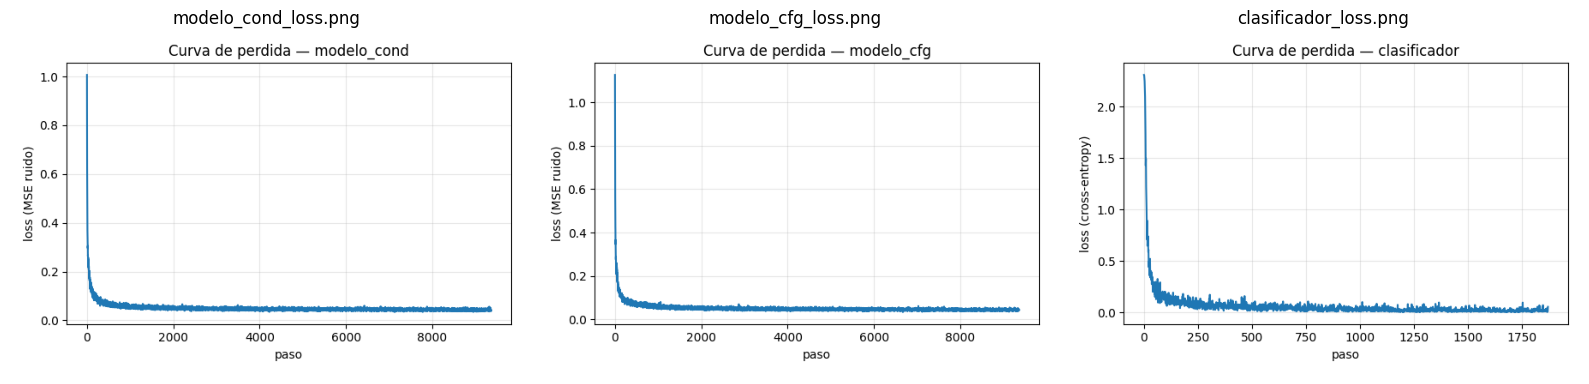

In [9]:
import matplotlib.pyplot as plt
from PIL import Image

loss_files = ["modelo_cond_loss.png", "modelo_cfg_loss.png", "clasificador_loss.png"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, name in zip(axes, loss_files):
    ax.imshow(Image.open(f"figures/loss/{name}"))
    ax.axis("off")
    ax.set_title(name)
plt.tight_layout()
plt.show()

## Muestreo (opcional)

Con los tres checkpoints ya entrenados, esta celda genera imágenes nuevas
integrando la SDE reversa (Euler–Maruyama, ver `sample.py`) y las muestra
lado a lado para comparar visualmente el efecto de CFG:

* **`modelo_cond`, `w=1`**: red condicional pura, sin guía adicional.

* **`modelo_cfg`, `w=1`**: misma red entrenada con CFG, pero sin aplicar guía (equivale al caso puramente condicional).

* **`modelo_cfg`, `w={w_cfg}`**: la misma red con guía CFG activa (`w>1`), que empuja las muestras hacia dígitos más *prototípicos* de su clase, a costa de menor diversidad dentro de cada clase.

Es opcional porque no hace falta para entrenar; sirve para inspeccionar cualitativamente los resultados antes de la evaluación cuantitativa de la celda siguiente.

*Nota técnica*: requiere que `sample.py` esté pusheado al repo remoto. Si
todavía no lo está, esta celda lo detecta y avisa en vez de fallar; sube
`sample.py`, vuelve a correr la celda de `git pull` de más arriba, y reintenta.

muestras guardadas en figures/samples/modelo_cond_w1.png
muestras guardadas en figures/samples/modelo_cfg_w1.png
muestras guardadas en figures/samples/modelo_cfg_w3.png


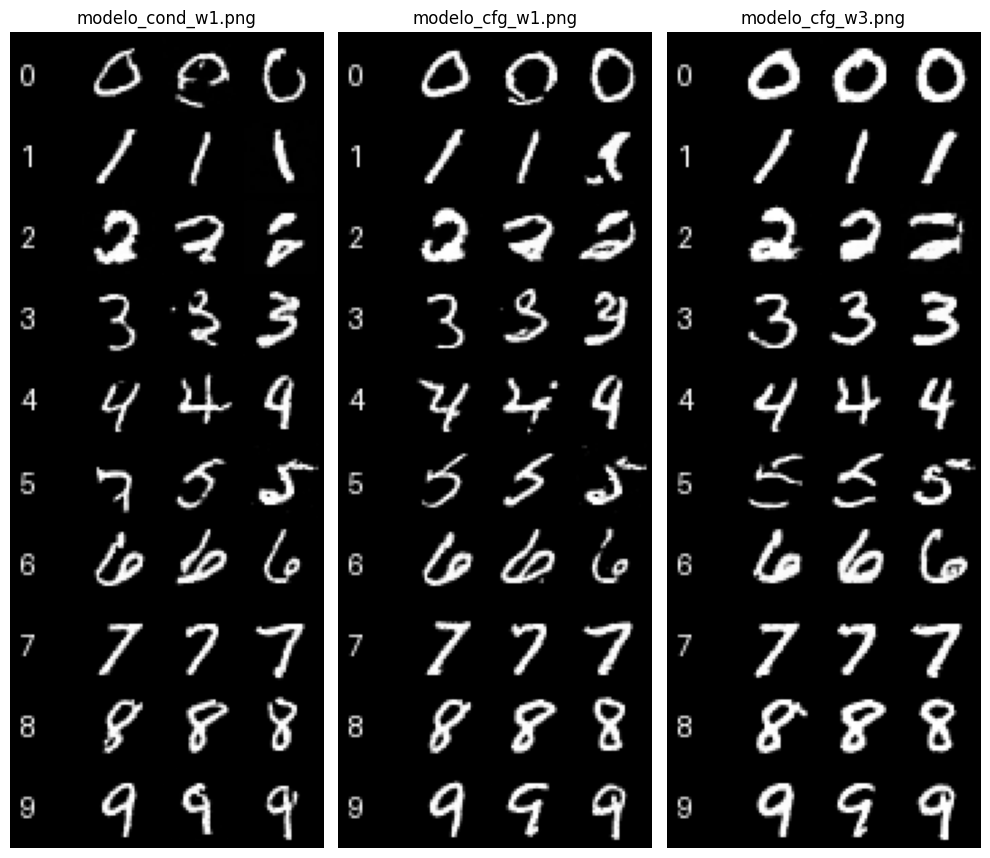

In [10]:
import os

if not os.path.exists("sample.py"):
    print("sample.py todavia no esta en el repo remoto (no fue pusheado).")
    print("Subelo, vuelve a correr la celda de clonado/pull, y reintenta esta celda.")
else:
    !python sample.py --checkpoint checkpoints/modelo_cond.pt \
      --n-steps {n_sampling_steps} --w 1.0 --n-samples 30 --device cuda \
      --seed {seed} --out figures/samples
    !python sample.py --checkpoint checkpoints/modelo_cfg.pt \
      --n-steps {n_sampling_steps} --w 1.0 --n-samples 30 --device cuda \
      --seed {seed} --out figures/samples
    !python sample.py --checkpoint checkpoints/modelo_cfg.pt \
      --n-steps {n_sampling_steps} --w {w_cfg} --n-samples 30 --device cuda \
      --seed {seed} --out figures/samples

    import matplotlib.pyplot as plt
    from PIL import Image

    sample_files = ["modelo_cond_w1.png", "modelo_cfg_w1.png", f"modelo_cfg_w{w_cfg:g}.png"]
    fig, axes = plt.subplots(1, 3, figsize=(10, 14))
    for ax, name in zip(axes, sample_files):
        ax.imshow(Image.open(f"figures/samples/{name}"))
        ax.axis("off")
        ax.set_title(name)
    plt.tight_layout()
    plt.show()

## Evaluación (`evaluate.py`)

Esta es la comparación cuantitativa (no solo visual) entre el modelo sin
guía y el modelo con guía: genera muestras nuevas con `modelo_cond` (`w=1`)
y con `modelo_cfg` (`w={w_cfg}`), y usa `clasificador.pt` como *juez*
automático para medir, por clase y en promedio:

* **Fidelidad condicional**: de las imágenes generadas pidiendo la clase `y`, ¿qué fracción reconoce el clasificador como `y`? Mide si el modelo genera lo que se le pidió.
  
* **Diversidad intra-clase**: distancia $L^2$ promedio entre pares de imágenes generadas para una misma clase. Mide si el modelo no colapsa a un único dígito *prototípico* por clase.

El resultado esperado (y el que se obtuvo en las corridas de referencia) es
que CFG (`w>1`) sube la fidelidad a costa de algo de diversidad: el guiado empuja las muestras hacia el *centro* de la clase.

*Nota técnica*: requiere que `sample.py` **y** `evaluate.py` estén pusheados al repo remoto (mismo chequeo defensivo que la celda de muestreo).

tabla guardada en figures/evaluate/fidelidad_diversidad.csv
grafico guardado en figures/evaluate/fidelidad_por_clase.png
grafico guardado en figures/evaluate/diversidad_por_clase.png
modelo_cond (w=1): fidelidad promedio=0.939  diversidad promedio=17.679
modelo_cfg (w=3): fidelidad promedio=1.000  diversidad promedio=16.873


,red,w,clase,fidelidad,diversidad
0,modelo_cond (w=1),1.0,0,0.940,19.619555
1,modelo_cond (w=1),1.0,1,0.970,13.042802
2,modelo_cond (w=1),1.0,2,0.860,19.038906
3,modelo_cond (w=1),1.0,3,0.930,18.924313
4,modelo_cond (w=1),1.0,4,0.950,17.372055
5,modelo_cond (w=1),1.0,5,0.970,18.736027
6,modelo_cond (w=1),1.0,6,0.970,18.344711
7,modelo_cond (w=1),1.0,7,0.970,16.634155
8,modelo_cond (w=1),1.0,8,0.910,18.440643
9,modelo_cond (w=1),1.0,9,0.920,16.634748


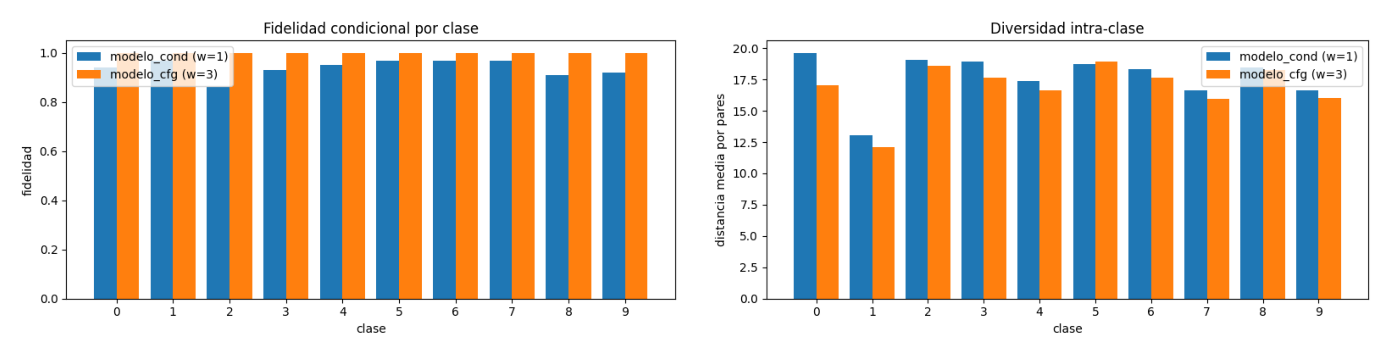

In [11]:
import os

if not (os.path.exists("sample.py") and os.path.exists("evaluate.py")):
    print("sample.py y/o evaluate.py todavia no estan en el repo remoto.")
    print("Subelos, vuelve a correr la celda de clonado/pull, y reintenta esta celda.")
else:
    !python evaluate.py --w {w_cfg} --n-samples 1000 --n-steps {n_sampling_steps} \
      --device cuda --seed {seed} --out figures/evaluate

    import pandas as pd
    import matplotlib.pyplot as plt
    from PIL import Image

    tabla = pd.read_csv("figures/evaluate/fidelidad_diversidad.csv")
    display(tabla)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].imshow(Image.open("figures/evaluate/fidelidad_por_clase.png"))
    axes[1].imshow(Image.open("figures/evaluate/diversidad_por_clase.png"))
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

## Descargar resultados

Empaqueta `checkpoints/` y `figures/` en un .zip para bajarlos al equipo
local (no se hace `git push` desde aca; el repo local sigue siendo la fuente
de verdad que tu decides cuando subir).

In [12]:
from google.colab import files

!zip -r -q /content/resultados_colab.zip checkpoints figures
files.download("/content/resultados_colab.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Informe

El desarrollo teórico completo (derivación de la pérdida DSM, la relación
entre $s_\theta$, $\epsilon_\theta$ y $u_\theta$, la regla de CFG, y el análisis de los resultados de fidelidad/diversidad) está en `informe/informe.pdf` del repositorio. Este notebook, más que nada, muestra el *cómo se reprodujo*, mientras que el informe es el *por qué* de cada decisión de diseño.